In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data/bidmc_01_Numerics.csv')
print(df.head())
print(df.columns)

Matplotlib is building the font cache; this may take a moment.


   Time [s]   HR   PULSE   RESP   SpO2
0         0   94    93.0     25   97.0
1         1   94    93.0     25   97.0
2         2   94    93.0     25   97.0
3         3   92    93.0     26   97.0
4         4   93    93.0     26   97.0
Index(['Time [s]', ' HR', ' PULSE', ' RESP', ' SpO2'], dtype='object')


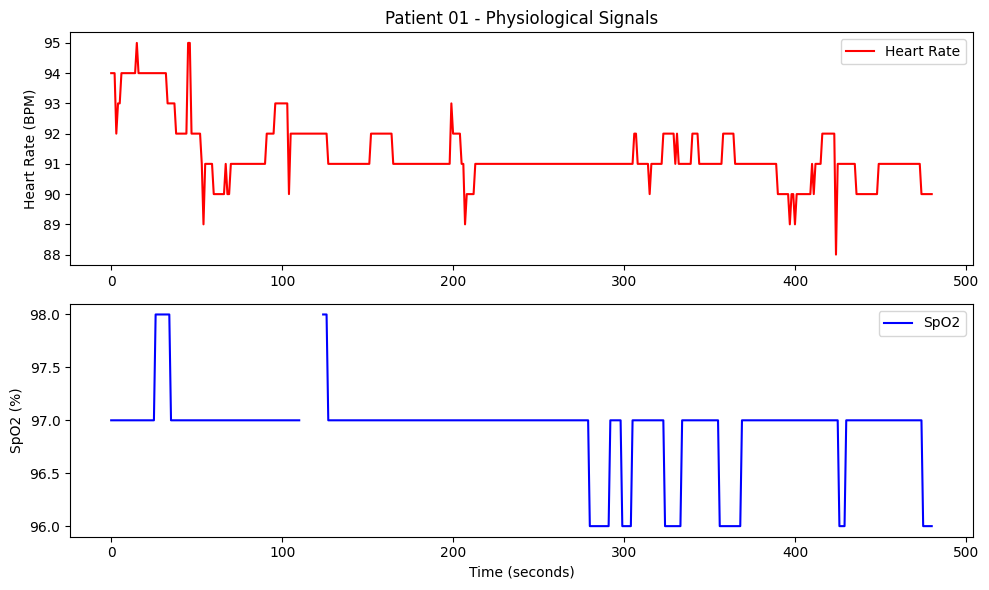

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(df['Time [s]'], df[' HR'], color='red', label='Heart Rate')
ax1.set_ylabel('Heart Rate (BPM)')
ax1.set_title('Patient 01 - Physiological Signals')
ax1.legend()

ax2.plot(df['Time [s]'], df[' SpO2'], color='blue', label='SpO2')
ax2.set_ylabel('SpO2 (%)')
ax2.set_xlabel('Time (seconds)')
ax2.legend()

plt.tight_layout()
plt.show()

Time [s]     0
 HR          0
 PULSE      13
 RESP        0
 SpO2       13
dtype: int64


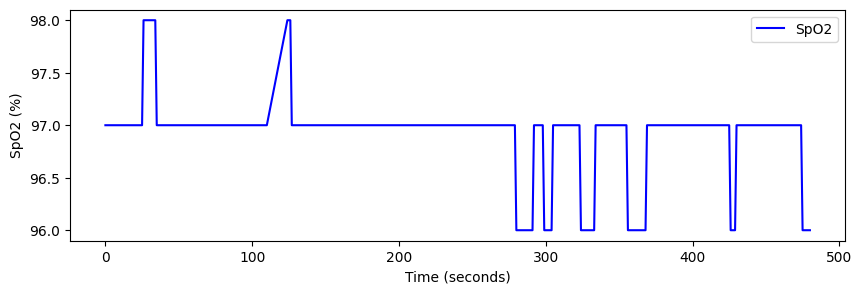

In [5]:
print(df.isnull().sum())

# Interpolate missing SpO2 values
df[' SpO2'] = df[' SpO2'].interpolate(method='linear')

# Replot to see the difference
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df['Time [s]'], df[' SpO2'], color='blue', label='SpO2')
ax.set_ylabel('SpO2 (%)')
ax.set_xlabel('Time (seconds)')
ax.legend()
plt.show()

/var/folders/3j/5n3vz0355wnf66lxydd0c03h0000gn/T/ipykernel_27053/2100242139.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[' SpO2'] = df[' SpO2'].fillna(method='ffill')


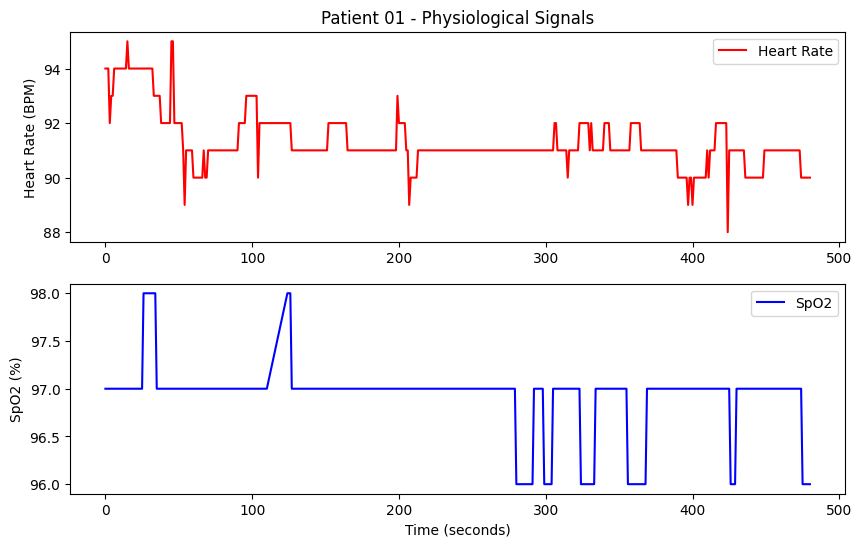

In [6]:
# Replace interpolation with forward fill
df[' SpO2'] = df[' SpO2'].fillna(method='ffill')

# Replot both
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(df['Time [s]'], df[' HR'], color='red', label='Heart Rate')
ax1.set_ylabel('Heart Rate (BPM)')
ax1.set_title('Patient 01 - Physiological Signals')
ax1.legend()

ax2.plot(df['Time [s]'], df[' SpO2'], color='blue', label='SpO2')
ax2.set_ylabel('SpO2 (%)')
ax2.set_xlabel('Time (seconds)')
ax2.legend()
plt.show()

In [7]:
# Checking time values to figure out why the interpolation is slanted even w/ forward fill
df_raw = pd.read_csv('data/bidmc_01_Numerics.csv')

# Show rows around the missing values
missing_idx = df_raw[df_raw[' SpO2'].isna()].index
print("Missing value indices:", missing_idx.tolist())

# Show 3 rows before and after the first gap
first_missing = missing_idx[0]
print(df_raw.iloc[first_missing-3 : first_missing+4])

Missing value indices: [111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123]
     Time [s]   HR   PULSE   RESP   SpO2
108       108   92    91.0     23   97.0
109       109   92    91.0     23   97.0
110       110   92    90.0     23   97.0
111       111   92     NaN     23    NaN
112       112   92     NaN     23    NaN
113       113   92     NaN     23    NaN
114       114   92     NaN     22    NaN


     Time [s]   HR   PULSE   RESP   SpO2
109       109   92    91.0     23   97.0
110       110   92    90.0     23   97.0
111       111   92    90.0     23   97.0
112       112   92    90.0     23   97.0
113       113   92    90.0     23   97.0
114       114   92    90.0     22   97.0
115       115   92    90.0     22   97.0
116       116   92    90.0     22   97.0
117       117   92    90.0     22   97.0
118       118   92    90.0     22   97.0
119       119   92    90.0     22   97.0
120       120   92    90.0     22   97.0
121       121   92    90.0     22   97.0
122       122   92    90.0     22   97.0
123       123   92    90.0     22   97.0
124       124   92    92.0     22   98.0
125       125   92    92.0     21   98.0
126       126   92    91.0     21   98.0


/var/folders/3j/5n3vz0355wnf66lxydd0c03h0000gn/T/ipykernel_27053/1984260201.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[' SpO2'] = df[' SpO2'].fillna(method='ffill')
/var/folders/3j/5n3vz0355wnf66lxydd0c03h0000gn/T/ipykernel_27053/1984260201.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[' PULSE'] = df[' PULSE'].fillna(method='ffill')


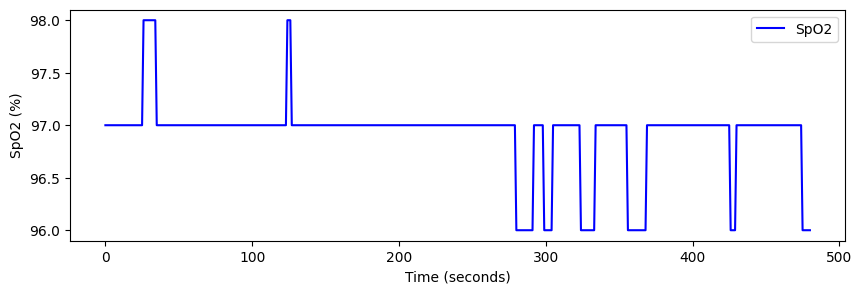

In [10]:
# Reload completely fresh
df = pd.read_csv('data/bidmc_01_Numerics.csv')

# Apply forward fill to the original NaN values
df[' SpO2'] = df[' SpO2'].fillna(method='ffill')
df[' PULSE'] = df[' PULSE'].fillna(method='ffill')

# Check the gap is now filled
print(df.iloc[109:127])

# Replot
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df['Time [s]'], df[' SpO2'], color='blue', label='SpO2')
ax.set_ylabel('SpO2 (%)')
ax.set_xlabel('Time (seconds)')
ax.legend()
plt.show()

In [ ]:
#Get stats for one patient
print(df.describe())

         Time [s]          HR       PULSE        RESP        SpO2
count  481.000000  481.000000  481.000000  481.000000  481.000000
mean   240.000000   91.318087   90.981289   21.438669   96.918919
std    138.997002    1.012765    1.133607    1.296181    0.353075
min      0.000000   88.000000   89.000000   20.000000   96.000000
25%    120.000000   91.000000   90.000000   21.000000   97.000000
50%    240.000000   91.000000   91.000000   21.000000   97.000000
75%    360.000000   92.000000   91.000000   22.000000   97.000000
max    480.000000   95.000000   94.000000   26.000000   98.000000


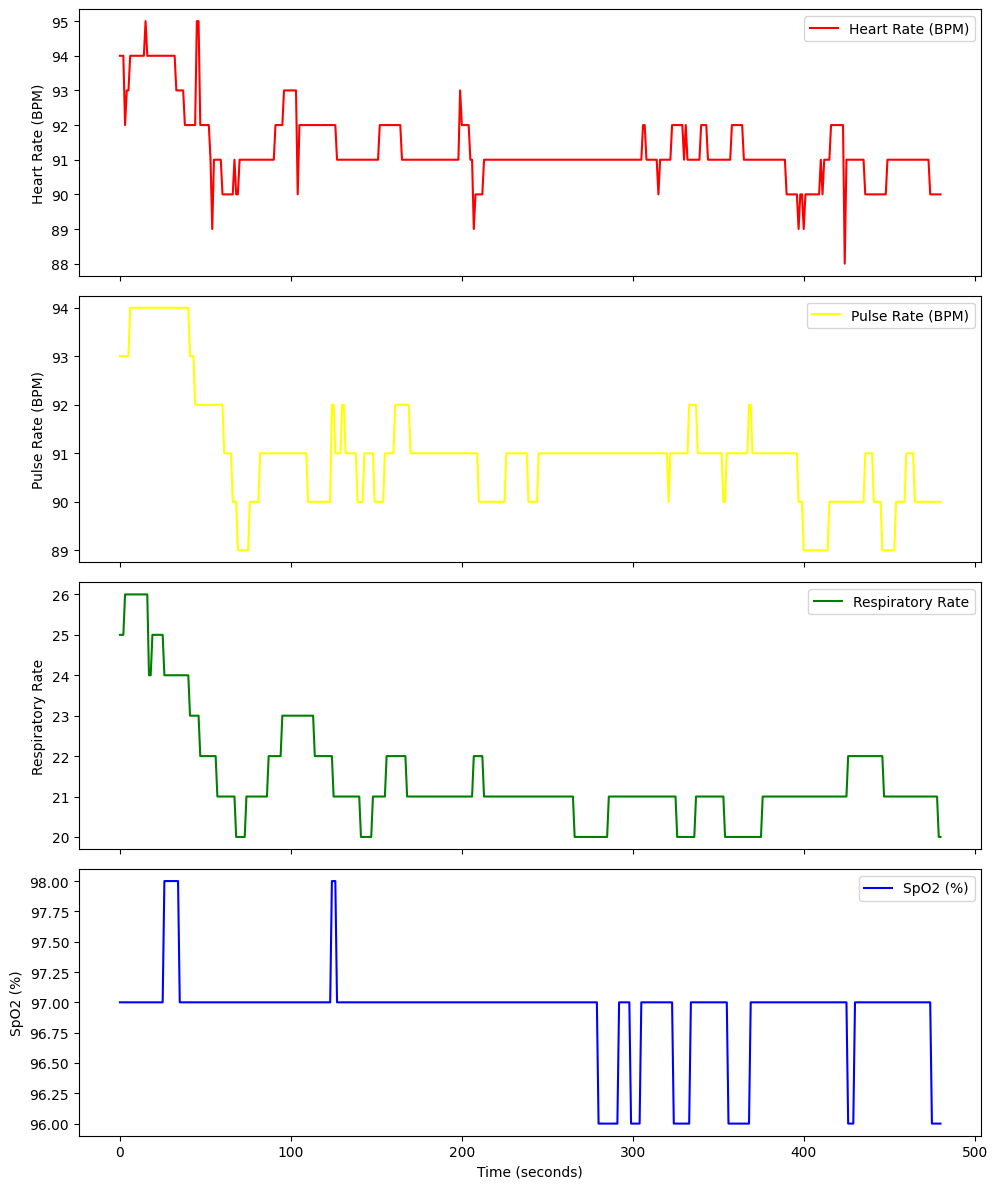

Text(0.5, 0.98, 'Patient 01 - All Physiological Signals')

<Figure size 640x480 with 0 Axes>

In [15]:
#Plotting all of the stats (HR, pulse, respt, sp02) together (use a loop)
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
signals = [' HR', ' PULSE', ' RESP', ' SpO2']
colors = ['red', 'yellow', 'green', 'blue']
labels = ['Heart Rate (BPM)', 'Pulse Rate (BPM)', 'Respiratory Rate', 'SpO2 (%)']

for i, (signal, color, label) in enumerate(zip(signals, colors, labels)):
    axes[i].plot(df['Time [s]'], df[signal], color=color, label=label)
    axes[i].set_ylabel(label)
    axes[i].legend()

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()  
plt.suptitle('Patient 01 - All Physiological Signals')